<a href="https://colab.research.google.com/github/jdansb/Econophysics/blob/main/files/fkkerplanck.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Versão completa

Procurando solução...
P inicial = 5.730087398677564e-05

========== RESÍDUO DA EDO ==========
Erro máximo : 0.00048274583008300204
Erro médio  : 6.500922788711882e-06

========== COMPARAÇÃO DAS INTEGRAIS ==========
Erro máximo em A = 3.397048906805811e-05
Erro máximo em B = 4.4812286671726265e-06


/tmp/ipykernel_404/669010009.py:109: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  A_int[i] = np.trapz(P[i:],w[i:])


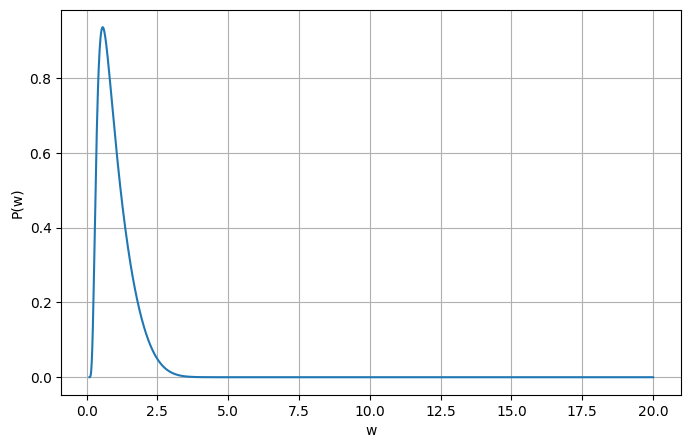

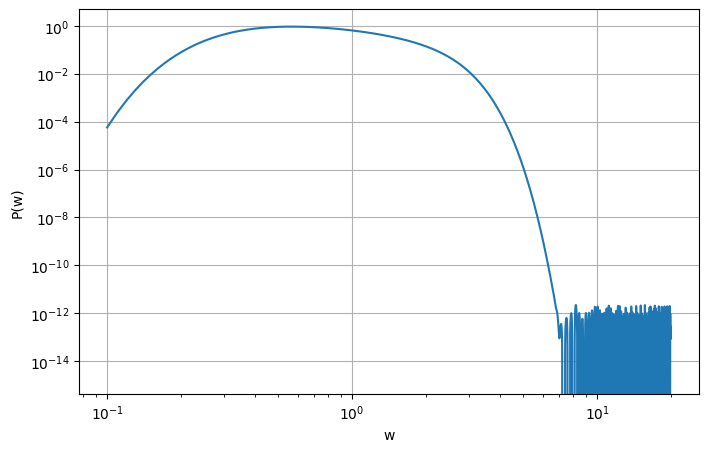

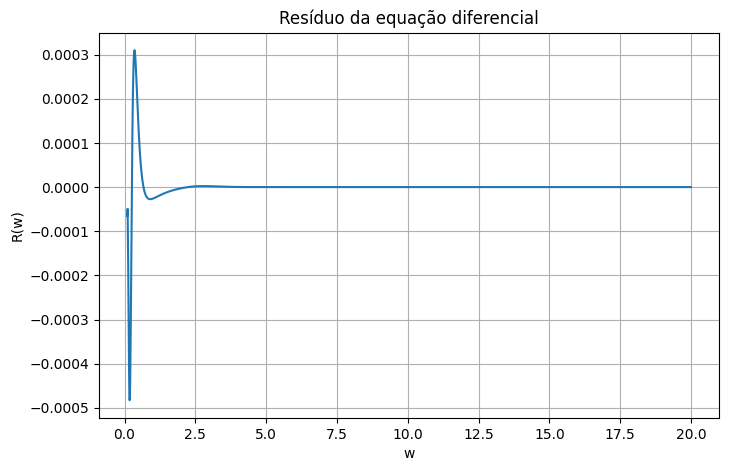

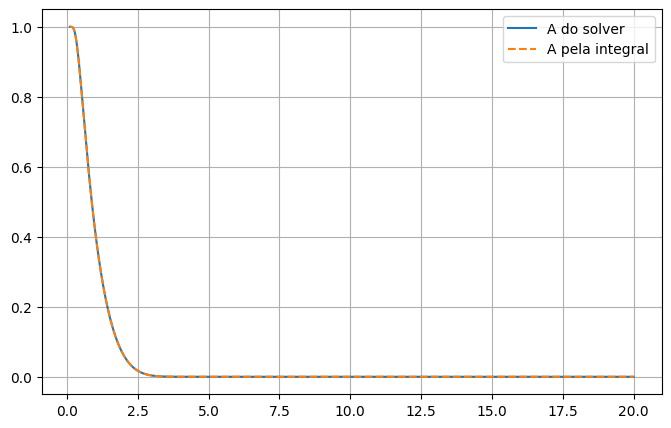

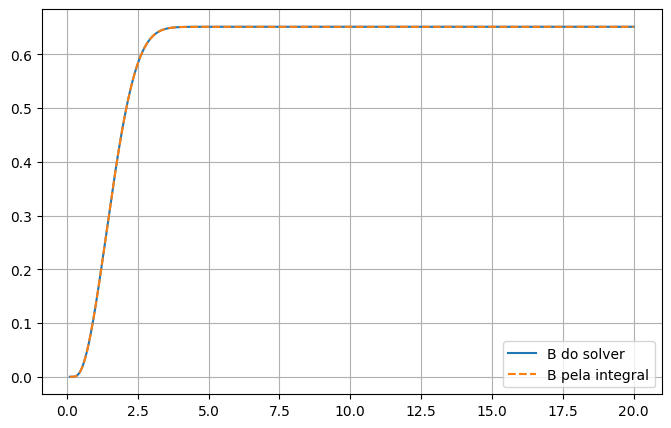

In [23]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp, cumulative_trapezoid
from scipy.optimize import root_scalar

# ====================================================
# Parâmetros
# ====================================================

tau = 1.0
beta = 1.0

lam = tau/(beta**2)

w_start = 0.1
w_end = 20.0

# ====================================================
# Sistema de EDOs
# ====================================================

def model_odes(w,y):

    P,A,B = y

    denom = 0.5*w**2*A + B

    if denom <= 1e-15:
        denom = 1e-15

    dP = ((lam*(1-w)-w*A)/denom)*P
    dA = -P
    dB = 0.5*w**2*P

    return [dP,dA,dB]

# ====================================================
# Método do tiro
# ====================================================

def shoot(p0):

    y0 = [p0,1.0,0.0]

    sol = solve_ivp(
        model_odes,
        [w_start,w_end],
        y0,
        method="RK45",
        rtol=1e-10,
        atol=1e-12
    )

    return sol.y[1,-1]

print("Procurando solução...")

res = root_scalar(
    shoot,
    bracket=[1e-10,2],
    method="brentq"
)

p0 = res.root

print("P inicial =",p0)

# ====================================================
# Solução final
# ====================================================

sol = solve_ivp(
    model_odes,
    [w_start,w_end],
    [p0,1.0,0.0],
    t_eval=np.linspace(w_start,w_end,2000),
    rtol=1e-10,
    atol=1e-12
)

w = sol.t
P = sol.y[0]
A = sol.y[1]
B = sol.y[2]

# ====================================================
# Verificação da EDO original
# ====================================================

Q = (0.5*w**2*A + B)*P

dQ = np.gradient(Q,w)

R = (1-w)*P - dQ

print()
print("========== RESÍDUO DA EDO ==========")
print("Erro máximo :",np.max(np.abs(R)))
print("Erro médio  :",np.mean(np.abs(R)))

# ====================================================
# Reconstrução de A pela definição
# ====================================================

A_int = np.zeros_like(w)

for i in range(len(w)-1):

    A_int[i] = np.trapz(P[i:],w[i:])

# ====================================================
# Reconstrução de B pela definição
# ====================================================

B_int = cumulative_trapezoid(
    0.5*w**2*P,
    w,
    initial=0
)

# ====================================================
# Erro entre solver e integrais
# ====================================================

erroA = A-A_int
erroB = B-B_int

print()
print("========== COMPARAÇÃO DAS INTEGRAIS ==========")
print("Erro máximo em A =",np.max(np.abs(erroA)))
print("Erro máximo em B =",np.max(np.abs(erroB)))

# ====================================================
# Gráficos
# ====================================================

plt.figure(figsize=(8,5))
plt.plot(w,P)
plt.xlabel("w")
plt.ylabel("P(w)")
plt.grid()

plt.figure(figsize=(8,5))
plt.loglog(w,P)
plt.xlabel("w")
plt.ylabel("P(w)")
plt.grid()

plt.figure(figsize=(8,5))
plt.plot(w,R)
plt.title("Resíduo da equação diferencial")
plt.xlabel("w")
plt.ylabel("R(w)")
plt.grid()

plt.figure(figsize=(8,5))
plt.plot(w,A,label="A do solver")
plt.plot(w,A_int,"--",label="A pela integral")
plt.legend()
plt.grid()

plt.figure(figsize=(8,5))
plt.plot(w,B,label="B do solver")
plt.plot(w,B_int,"--",label="B pela integral")
plt.legend()
plt.grid()

plt.show()

# Versão assintótica

Erro máximo : 4.822824132647303e-11
Erro médio  : 2.7363150983795493e-12


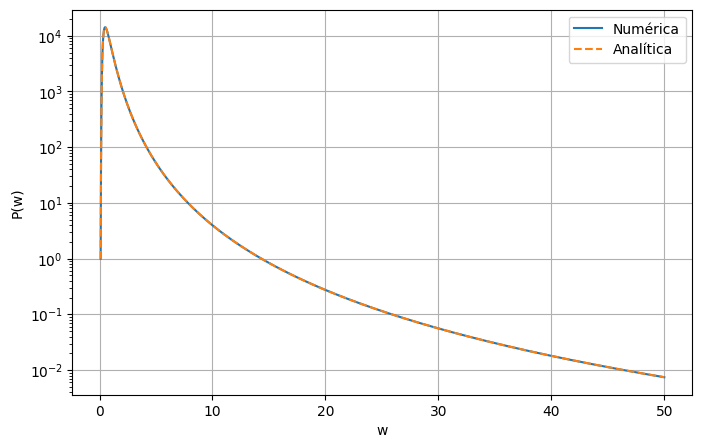

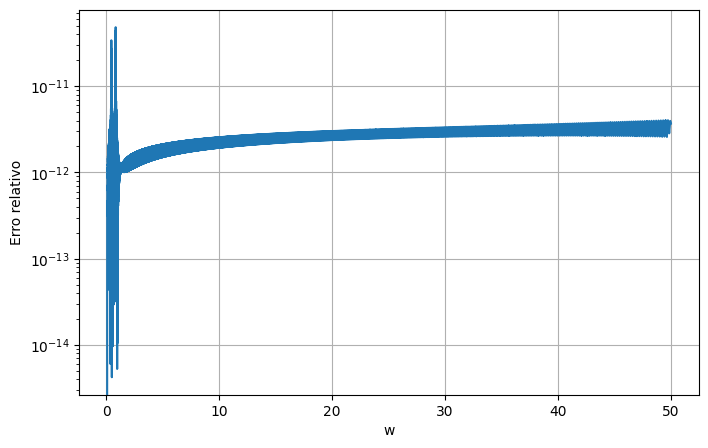

In [35]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

chi = 1

# ----------------------------
# Equação (22)
# ----------------------------

def ode22(w, y):
    P = y[0]
    dP = (2*chi/w**2 - 2*(chi+1)/w) * P
    return [dP]

# ----------------------------
# Condição inicial
# ----------------------------

w0 = 0.1
wf = 50.0

P0 = 1.0

sol = solve_ivp(
    ode22,
    [w0, wf],
    [P0],
    t_eval=np.linspace(w0, wf, 100000),
    rtol=1e-12,
    atol=1e-14
)

w = sol.t
P_num = sol.y[0]

# ----------------------------
# Solução analítica normalizada
# para coincidir em w0
# ----------------------------

P_exact = P0 * np.exp(
    2*chi*(1/w0 - 1/w)
) * (w0/w)**(2*(chi+1))

# ----------------------------
# Erro relativo
# ----------------------------

erro = np.abs(P_num - P_exact)/P_exact

print("Erro máximo :", np.max(erro))
print("Erro médio  :", np.mean(erro))

# ----------------------------
# Gráficos
# ----------------------------

plt.figure(figsize=(8,5))
plt.semilogy(w, P_num, label="Numérica")
plt.semilogy(w, P_exact, "--", label="Analítica")
plt.xlabel("w")
plt.ylabel("P(w)")
plt.legend()
plt.grid()

plt.figure(figsize=(8,5))
plt.semilogy(w, erro)
plt.xlabel("w")
plt.ylabel("Erro relativo")
plt.grid()

plt.show()

P inicial = 5.730087398651105e-05

========== TESTE 1 ==========
Resíduo máximo = 0.00012115966372745757
Resíduo médio  = 1.6253543467930464e-06

========== TESTE 2 ==========
Erro máximo A = 8.49010270864703e-06
Erro máximo B = 1.1198802475857056e-06

========== TESTE 3 ==========
A médio = 0.9941458392415766
A mínimo = 0.9738273026539732
A máximo = 1.0

B médio = 0.00016088432067751506
B máximo = 0.0008716686334052819

========== TESTE 4 ==========
Erro aproximação Eq.22 = 0.004650099289411402


/tmp/ipykernel_404/2996704860.py:103: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  A_int[i] = np.trapz(P[i:],w[i:])


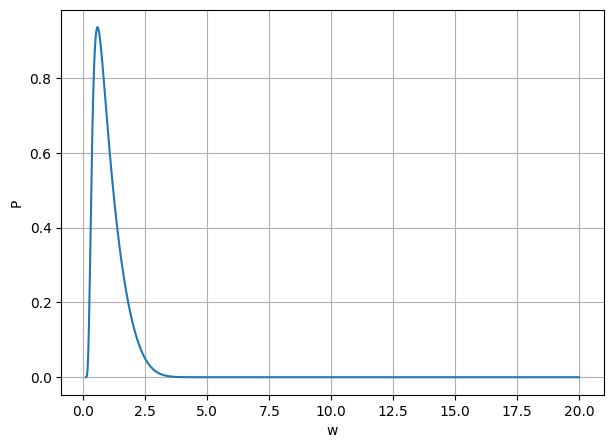

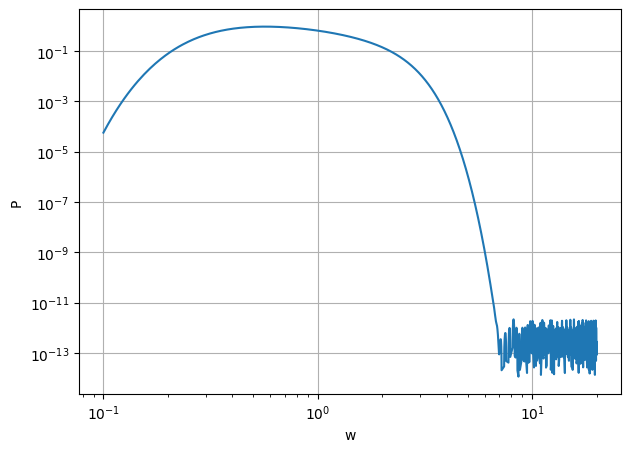

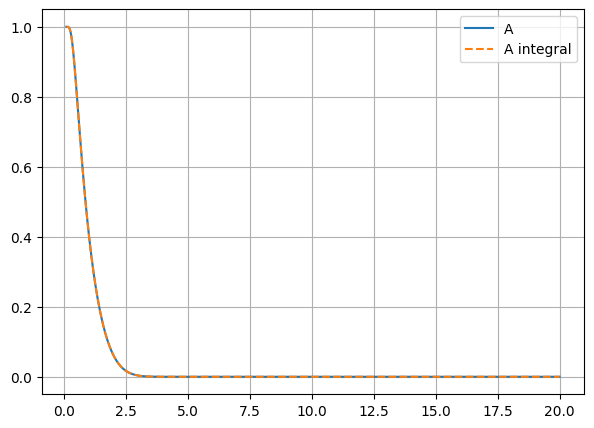

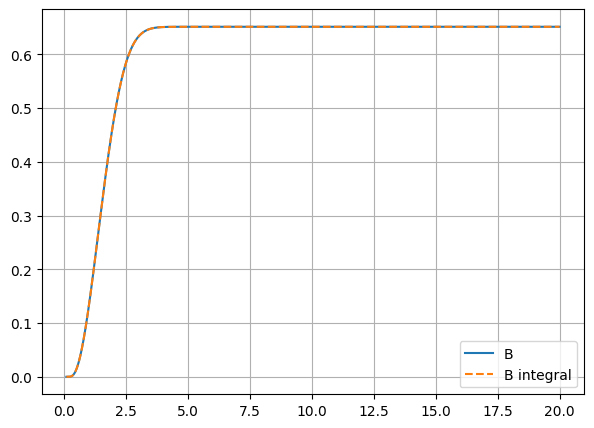

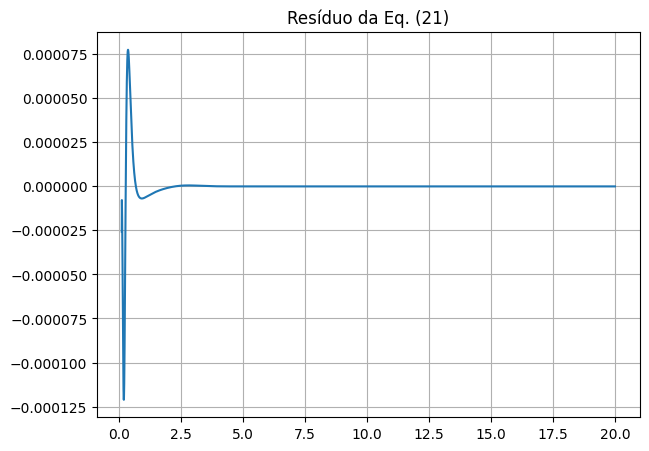

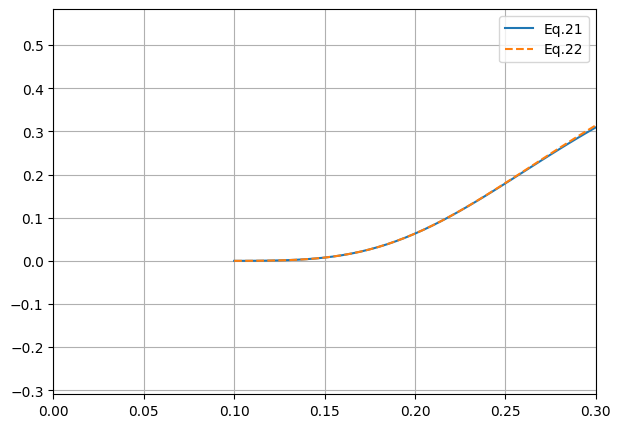

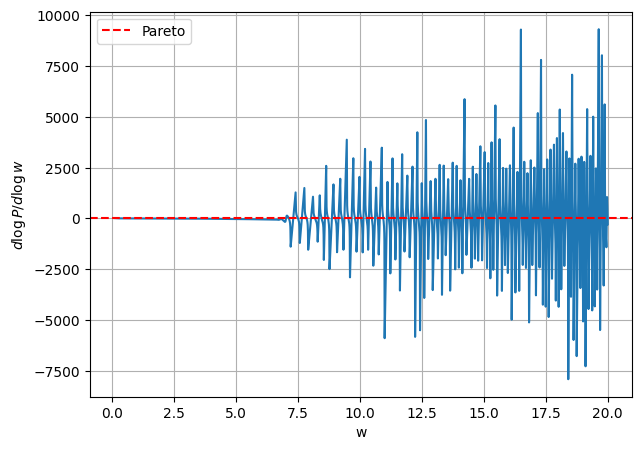

In [37]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp, cumulative_trapezoid
from scipy.optimize import root_scalar

# =====================================================
# PARÂMETROS
# =====================================================

chi = 1

w_start = 0.1
w_end   = 20

# =====================================================
# SISTEMA DE EDOS
# =====================================================

def ode(w,y):

    P,A,B = y

    denom = 0.5*w*w*A + B

    if denom < 1e-15:
        denom = 1e-15

    dP = ((chi*(1-w)-w*A)/denom)*P
    dA = -P
    dB = 0.5*w*w*P

    return [dP,dA,dB]

# =====================================================
# MÉTODO DO TIRO
# =====================================================

def shoot(P0):

    sol = solve_ivp(
        ode,
        [w_start,w_end],
        [P0,1,0],
        rtol=1e-10,
        atol=1e-12
    )

    return sol.y[1,-1]

res = root_scalar(
    shoot,
    bracket=[1e-10,2],
    method='brentq'
)

P0 = res.root

print("P inicial =",P0)

# =====================================================
# SOLUÇÃO FINAL
# =====================================================

sol = solve_ivp(
    ode,
    [w_start,w_end],
    [P0,1,0],
    t_eval=np.linspace(w_start,w_end,4000),
    rtol=1e-10,
    atol=1e-12
)

w = sol.t
P = sol.y[0]
A = sol.y[1]
B = sol.y[2]

# =====================================================
# TESTE 1
# RESÍDUO DA EDO
# =====================================================

Q = (0.5*w**2*A+B)*P

dQ = np.gradient(Q,w)

R = chi*(1-w)*P-dQ

print()
print("========== TESTE 1 ==========")
print("Resíduo máximo =",np.max(np.abs(R)))
print("Resíduo médio  =",np.mean(np.abs(R)))

# =====================================================
# TESTE 2
# RECONSTRUÇÃO DE A
# =====================================================

A_int = np.zeros_like(w)

for i in range(len(w)-1):

    A_int[i] = np.trapz(P[i:],w[i:])

# =====================================================
# TESTE 3
# RECONSTRUÇÃO DE B
# =====================================================

B_int = cumulative_trapezoid(
    0.5*w**2*P,
    w,
    initial=0
)

print()
print("========== TESTE 2 ==========")
print("Erro máximo A =",np.max(np.abs(A-A_int)))
print("Erro máximo B =",np.max(np.abs(B-B_int)))

# =====================================================
# TESTE 4
# HIPÓTESE DO ARTIGO
# A≈1
# B≈0
# =====================================================

mask = w<0.3

print()
print("========== TESTE 3 ==========")

print("A médio =",np.mean(A[mask]))
print("A mínimo =",np.min(A[mask]))
print("A máximo =",np.max(A[mask]))

print()

print("B médio =",np.mean(B[mask]))
print("B máximo =",np.max(B[mask]))

# =====================================================
# TESTE 5
# EQUAÇÃO 22
# =====================================================

Qapprox = 0.5*w**2*P

dQapprox = np.gradient(Qapprox,w)

mask = w<0.3

erro22 = np.max(np.abs(dQ[mask]-dQapprox[mask]))

print()
print("========== TESTE 4 ==========")
print("Erro aproximação Eq.22 =",erro22)

# =====================================================
# TESTE 6
# EXPOENTE LOCAL
# =====================================================

mask = (P>1e-14)

alpha = np.gradient(
    np.log(P[mask]),
    np.log(w[mask])
)

# =====================================================
# GRÁFICOS
# =====================================================

plt.figure(figsize=(7,5))
plt.plot(w,P)
plt.xlabel("w")
plt.ylabel("P")
plt.grid()

plt.figure(figsize=(7,5))
plt.loglog(w[mask],P[mask])
plt.xlabel("w")
plt.ylabel("P")
plt.grid()

plt.figure(figsize=(7,5))
plt.plot(w,A,label="A")
plt.plot(w,A_int,"--",label="A integral")
plt.legend()
plt.grid()

plt.figure(figsize=(7,5))
plt.plot(w,B,label="B")
plt.plot(w,B_int,"--",label="B integral")
plt.legend()
plt.grid()

plt.figure(figsize=(7,5))
plt.plot(w,R)
plt.title("Resíduo da Eq. (21)")
plt.grid()

plt.figure(figsize=(7,5))
plt.plot(w[mask],dQ[mask],label="Eq.21")
plt.plot(w[mask],dQapprox[mask],'--',label="Eq.22")
plt.xlim(0,0.3)
plt.legend()
plt.grid()

plt.figure(figsize=(7,5))
plt.plot(w[mask],alpha)
plt.axhline(-3,color='r',ls='--',label='Pareto')
plt.xlabel("w")
plt.ylabel(r"$d\log P/d\log w$")
plt.legend()
plt.grid()

plt.show()

In [38]:
erro_relativo = np.max(np.abs((dQ-dQapprox)/dQ))

In [39]:
erro_relativo

np.float64(4135.131906891727)

In [40]:
dQ

array([ 7.72564418e-05,  1.16759949e-04,  2.25404699e-04, ...,
        2.57376159e-12, -6.38449553e-13, -2.57736138e-12])